<h1>Ecole Polytechnique de Thies</h1>
<h2>Département du Génie Informatique et Télécommunications<br/>
Master en Ingénierie Logicielle et Intelligence Artificielle
<br/>
2025/2026</h2>
<p>
Dr Samba SIDIBE
</p>

<h1>Regression linéaire, equation normale, vectorisation<h1>

<h1> Exercice 1: Regression linéaire, equation normale<h1>
<p>
La régression linéaire est un algorithme d’apprentissage supervisé de type régression. Les algorithmes de régression permettent de prédire des valeurs continues à partir des variables prédictives. Le principe est de trouver une droite qui se rapproche le plus possible d’un ensemble de points (points d’entraînement).
</p>
<p>
Considérons l’équation de prédiction d’un modèle de régression linéaire suivante:

$$
\widehat{y} = h_θ(x) = θ^T.x= θ_0+ θ_1x_1 +…+θ_nx_n\tag{1,1}
$$

où $θ=\begin{bmatrix}θ_0 \\θ_1 \\ \vdots \\θ_n \end{bmatrix}$ est le vecteur des paramètres du modèle, $θ^T$ transposé de θ, x vecteur des valeurs d’une observation, $θ^T.x$ est le produit scalaire de $θ^T$ et x et $h_θ$ est la fonction hypothèse utilisant les paramètres θ.
</p>

<p>
Pour la suite nous allons considerer une fonction affine univariée eq[1.2] puis y ajouter du bruit et determiner le model de regression
$$
f(x)=4+3x\tag{1,2}
$$


1. Generation des donnees d'entrainement

le module random contient une fonction $random()$ permettant de generer un nombre aleatoire dans l'intervalle $[0,1[$

1.1. Generer un nombre $xMin$ aleatoire compris entre -10 et 2 qui sera notre $x$ minimum et un nombre $deltaX$ entre 10 et 20 qui sera la distance maximale entre deux x. On a $xMax=xMin+deltaX$



In [183]:
import random

#generer de maniere aleatoire un entier xMin dans [-10, 2]
xMin=random.random()*12-10


#generer deltaX la largeur de l'intervalle compris entre 10 et 20
deltaX=random.random()*10+10

#Deduction de xMax
xMax=xMin+ deltaX

#affichage variables xMin, deltaX, xMax
print(f"xMin = {xMin}")
print(f"deltaX = {deltaX}")
print(f"xMax = {xMax}")

xMin = -7.022897473493083
deltaX = 16.313678756694436
xMax = 9.290781283201353


1-2 Vecteur x d'entrainement

La fonction $np.random.rand(n,m)$ de la librairie numpy permet de generer une matrice aleatoire de n lignes et m colonnes. (Voir la documentation numpy)

Generer un vecteur aleatoire $x$ de dimension 20 dont les elements $x_i$ sont entre xMin et xMax



In [184]:
#générer x  avec des elements appartenant a l'intervalle [xMin, xMax]
import numpy as np

x = np.random.rand(20) * (xMax-xMin)+xMin

#affichage de X
print(F"X = {x}")
#affichage de la dimension de x
print("shape",x.shape)

X = [-0.6399773   7.31483289  0.27031942  7.87872847  6.94276842 -2.4404131
  0.99397882  9.26129259 -5.27446537  7.08854767  4.92860384  0.32530908
  6.72137053  4.40103764 -6.38462039  7.39123795  2.99114227 -4.45900444
  2.64009061  6.25060684]
shape (20,)


1.3. Calculer F=f(X) f etant la fonction definie en (1,2)

In [185]:
#calculer F
F = 4 + 3 * x
#affichage de la valeur de f
print(F"F={F}")

F=[  2.0800681   25.94449868   4.81095825  27.63618541  24.82830526
  -3.32123931   6.98193646  31.78387778 -11.82339611  25.265643
  18.78581152   4.97592725  24.1641116   17.20311291 -15.15386117
  26.17371384  12.9734268   -9.37701331  11.92027183  22.75182051]


1.4. Pour determiner Y on va prendre $F$ et y ajouter du bruit gaussien. Puis on va afficher y et f(x) pour visualiser les données.


Le resultat donne une figure qui ressemble à l'image suivante


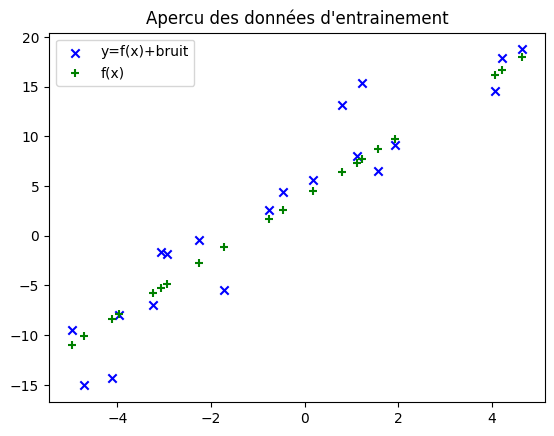


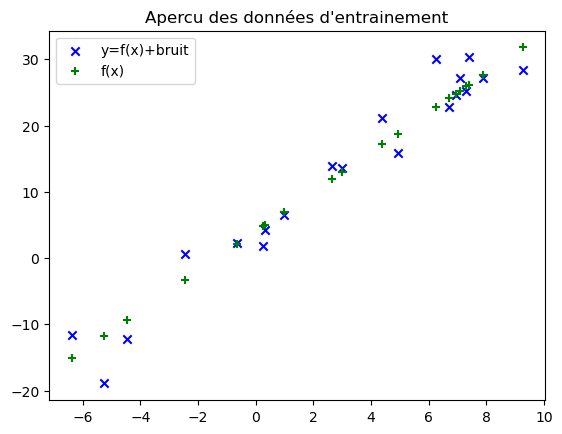

In [186]:
import matplotlib.pyplot as plt

#ajout du bruit a F
Y = F + np.random.normal(0,3,len(x))

#Visualisation des donnees
plt.scatter(x, Y, marker='x', color='b', label='Y')
plt.scatter(x, F, marker='+', color='g', label='F')
plt.title("Apercu des données d'entrainement")
plt.legend(['y=f(x)+bruit', 'f(x)'])
plt.show()

2. Regression lineaire

2.1. L’équation de régression lorsque les entrées sont composées d’une seule valeur x est donnée par

$$
\widehat{y}_i = θ_0 + θ_1x_1 = [1, x_1]\begin{bmatrix}θ_0 \\θ_1 \end{bmatrix}
$$

posons $X$ la matrice 2 deux colonnes dont les elements de la premiere colonne ont comme valeur 1 et $x_i$ l'element de la deuxieme colonne à la ligne $i$, $\widehat{Y}$ le vecteur constitue par les $\widehat{y}_i$

On a alors

$\widehat{Y}=h_θ(X) = Xθ$

l'erreur quadratique moyenne peux se calculer par :

$E=\sum_{i=1}^N{(y-y_i)^2} $

Calculer les erreurs quadratiques $E_1, E_2, E_3$ pour $θ$ egale aux valeurs successives suivantes:  $theta1=\begin{bmatrix}3 \\7/2 \end{bmatrix}$,
 $theta2=\begin{bmatrix}5 \\5/2 \end{bmatrix}$ et $theta3 \begin{bmatrix}4 \\3 \end{bmatrix}$




In [187]:
#Calculer X,  la premiere colonne ayant des valeurs egale à 1 et
# la deuxieme colonne etant les x_i vous pouvez utiliser les fonctions numpy
# np.ones(var) et np.c_[a,b](voir documentation)
X=np.c_[np.ones(len(x)),x]

theta1=[3,7/2]
theta2=[4,5/2]
theta3=[4,3]

Y1= X @ theta1
e=Y-Y1
E1 = e @ e.T


Y2= X @ theta2
e=Y-Y2
E2 = e @ e.T


Y3= X @ theta3
e=Y-Y3
E3 = e @ e.T


#affichage des erreurs quadratique
print(F"E1 {E1}")
print(F"E2 {E2}")
print(F"E3 {E3}")




E1 268.96406004658024
E2 425.51088838563373
E3 212.79046534382906


2.2. Parmis $θ_1$, $θ_2$ et $θ_3$ quel est le meilleur model <br/>
<span style="color : green;"> theta3 est le meilleur model </span>

2.3 Creer une figure y placer les points (x<sub>i</sub>,y<sub>i</sub>)

2.4 Pour chaque model θ predire la valeur yMin de xMin et la valeur yMax de xMax

2.5 Pour chaque θ tracer la prediction des x qui sont sur l'intervalle delimitee par les points (xMin, yMin) et (xMax, yMax) (c'est le segment delimité par les points (xMin, yMin) et (xMax, yMax).)

Vous aurez une figure qui ressemble à la figure ci dessous

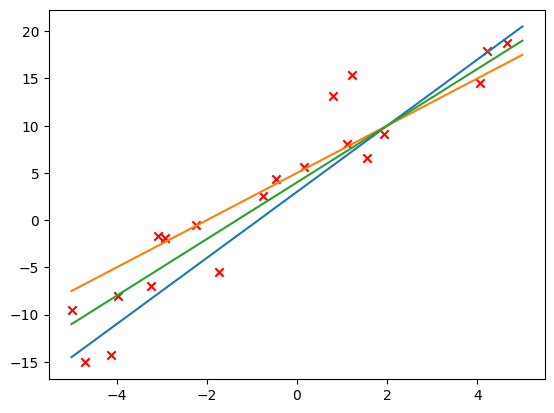



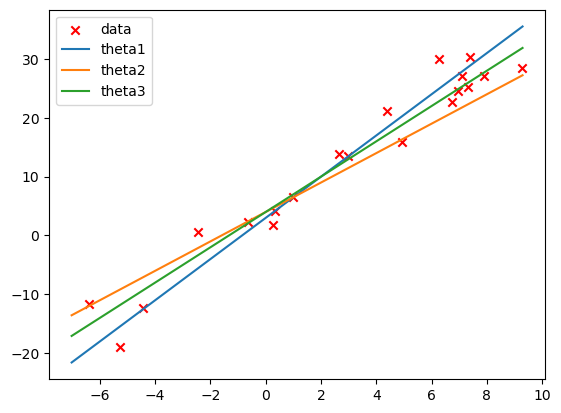

In [188]:
#afficher
#affichage des points x_i,y_i
plt.scatter(x, Y, marker='x', color='r', label='data')


#afficher des predictions pour les models theta1, theta2 et theta3
xx=np.array([xMin,xMax])
plt.plot(xx,(theta1[0] + theta1[1] * xx),label="theta1") #pour theta1
plt.plot(xx,(theta2[0] + theta2[1] * xx),label="theta2") #pour theta2
plt.plot(xx,(theta3[0] + theta3[1] * xx),label="theta3") #pour theta3
plt.legend()
plt.show()

3. Solution optimale : Equation normale

La solution analytique θ qui minimise la fonction coût est donnée par l’équation normale suivante:
$$
\widehat{θ}=(X^T.X)^{-1}.X^T.y
$$

3.1. Calculer $\widehat{θ}$

3.2. Placer les points (x<sub>i</sub>, y<sub>i</sub>)

3.3. En utilisant la solution analytique, tracer la prediction des x  qui sont sur l'intervalle delimitee par les points (xMin, yMin) et (xMax, yMax) (c'est le segment delimité par les points (xMin, yMin) et (xMax, yMax).)

le resultat resultat ressemblera a la figure suivante

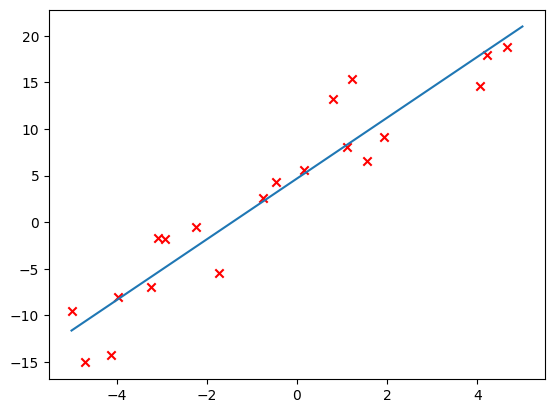

thetaBest [3.85810963 3.12138075]


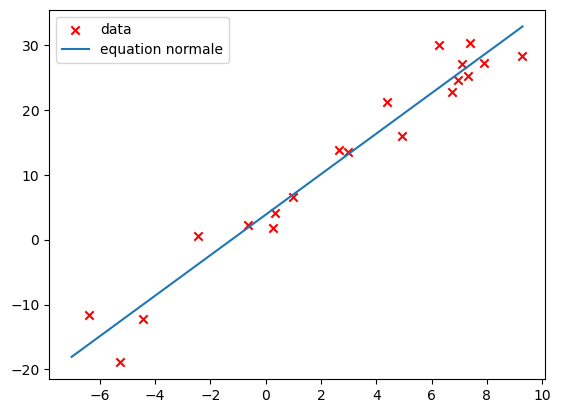

In [202]:
# Calcul de theta chapeau thetaBest
# vous pouvez utiliser les fonction numpy suivantes np.linalg.inv
# X.T pour calculer le transposé d'une matrice X
# X.dot(Y) pour calculer le produit de deux matrices

thetaBest=np.linalg.inv(X.T @ X) @ X.T @ Y #calcule thetaBest
print("thetaBest",thetaBest)

#placement des points x_i, yi
plt.scatter(x, Y, marker='x', color='r', label='data')

#tracer les predictions des points x sur [xMin, xMax]
plt.plot(xx,(thetaBest[0] + thetaBest[1] *xx),label="equation normale")
plt.legend()
plt.show()

<h1>Exercice 2 : importance de la vectorisation</h1>

Le produit scalaire d'un vecteur-ligne x<sup>T</sup> par un vecteur-colonne y est donné par la formule suivante :
$$
x^Ty=\begin{bmatrix}x_1 x_2 \dots x_n\end{bmatrix}\begin{bmatrix}y_1 \\y_2 \\ \vdots \\y_n \end{bmatrix}=x_1y_1+x_2y_2+\dots+x_ny_n=\sum_{i=1}^nx_iy_i
$$

Le produit de la matrice A (n × m) par la matrice B (m × p) est la matrice C (n × p) telle que l'élément $C_{ij}$(ligne i, colonne j)  est égal au produit scalaire de la ligne i de la matrice A par la colonne j de la matrice B

$$
C_{ij}=\sum_{k=1}^nA_{ik}B_{kj}
$$

1. Creer une fonction permettant de calculer le produit de deux matrices en utilisant des boucles

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# produit de matrice utilisant une boucle
def product_loop(A, B):
    n, m = A.shape  # dimensions de A
    m2, p = B.shape  # dimensions de B
    assert m == m2, "Dimensions incompatibles"  # vérification de compatibilité
    
    C = np.zeros((n, p))
    for i in range(n):
        for j in range(p):
            for k in range(m):
                C[i, j] += A[i, k] * B[k, j]  # calcul du produit
    
    resultat = C
    return resultat


A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("product_loop :\n", product_loop(A, B))

2. Creer une fonction permettant de calculer le produit de deux matrice en utilisant la fonction dot de numpy

In [ ]:
# produit de matrice utilisant une vectorisation numpy
def product_numpy(A, B):
    resultat = np.dot(A, B) 
    return resultat

print("product_numpy :\n", product_numpy(A, B))

3. Calculer le temps de calcule de produit de matrices carrees dont les dimension sont successivement 10, 100, 1000, .., 10000000
vous pouvez utiliser le module $time$ de python pour determiner les temps de calcul. Les matrices peuvent etre generees de maniere aleatoire avec numpy

In [ ]:
sizes_loop  = [10, 100, 200,300]          


times_loop  = []
times_numpy = []


# Mesure pour product_loop
for n in sizes_loop:
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    start = time.time()
    product_loop(A, B)
    end = time.time()
    times_loop.append(end - start)
    print(f"Loop  | taille {n:5d} → {end - start:.4f} s")
    start = time.time()
    product_numpy(A, B)
    end = time.time()
    times_numpy.append(end - start)
    print(f"Numpy | taille {n:5d} → {end - start:.6f} s")
print()




4. Tracer sur une meme figure les courbes illustrant le temps de calcul en fonction de la taille de la matrice

In [ ]:
#tracer les courbes
fig, ax = plt.subplots(figsize=(10, 6))

# Courbe boucles et numpy sur le même graphique
ax.plot(sizes_loop, times_loop, 'o-', color='red', linewidth=2, label='Boucles Python', markersize=8)
ax.plot(sizes_loop, times_numpy, 's-', color='steelblue', linewidth=2, label='NumPy (dot)', markersize=8)

ax.set_title("Importance de la vectorisation — Produit matriciel", fontsize=14, fontweight='bold')
ax.set_xlabel("Taille de la matrice (n×n)", fontsize=12)
ax.set_ylabel("Temps (secondes)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("vectorisation_comparaison.png", dpi=150)
plt.show()